<a href="https://colab.research.google.com/github/ankitta-singh/machinelearning/blob/main/11_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [ ]:
import zipfile
with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip","r") as zip_ref:
  zip_ref.extractall("house data")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression



In [ ]:
df = pd.read_csv("house data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
X = df.drop("SalePrice",axis=1)
y = df["SalePrice"]

In [ ]:
y

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


In [ ]:
X= pd.get_dummies(X,drop_first=True)
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.30,random_state=42)

In [ ]:
X_train

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
135,136,20,80.0,10400,7,6,1970,1970,288.0,0,...,False,False,False,False,True,False,False,False,True,False
1452,1453,180,35.0,3675,5,5,2005,2005,80.0,547,...,False,False,False,False,True,False,False,False,True,False
762,763,60,72.0,8640,7,5,2009,2009,0.0,24,...,False,False,False,False,False,False,False,False,True,False
932,933,20,84.0,11670,9,5,2006,2006,302.0,0,...,False,False,False,False,True,False,False,False,True,False
435,436,60,43.0,10667,7,6,1996,1996,0.0,385,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1096,20,78.0,9317,6,5,2006,2006,0.0,24,...,False,False,False,False,True,False,False,False,True,False
1130,1131,50,65.0,7804,4,3,1928,1950,0.0,622,...,False,False,False,False,True,False,False,False,True,False
1294,1295,20,60.0,8172,5,7,1955,1990,0.0,167,...,False,False,False,False,True,False,False,False,True,False
860,861,50,55.0,7642,7,8,1918,1998,0.0,0,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()


In [ ]:
from sklearn.model_selection import cross_val_score
regression= LinearRegression()
regression.fit(X,y)

LinearRegression()

In [ ]:
mse=cross_val_score(regression,X_train,y_train,scoring="neg_mean_squared_error",cv=5)

In [ ]:
np.mean(mse)

np.float64(-1880468056.0747597)

In [ ]:
reg_pred=regression.predict(X_test)

In [ ]:
reg_pred

array([158766.23808112, 348361.07053489,  93857.97186892, 175361.1600035 ,
       322125.8745919 ,  75864.1911178 , 245437.05742813, 145558.13609849,
        71857.28286615, 147747.56692918, 147569.90262768, 103905.64625958,
        67698.11069613, 219430.9830877 , 170414.86895498, 133468.7061454 ,
       187483.87320587, 124642.55204786, 124765.99921897, 215204.82316325,
       156630.46426445, 202347.77059719, 172219.61777834, 129871.10615263,
       198687.40850777, 144376.79165689, 197901.18782381, 110525.16591142,
       175930.42945763, 204774.64890628, 137432.04561113, 275795.92308795,
       233178.01984073, 114170.49960503, 240458.51688496, 143907.50625018,
       139176.42930417, 200977.38514831, 312346.70032466, 117999.34581419,
       109179.10073211, 227162.18045345, 105124.31078653, 363384.84829278,
       127887.14358044, 135743.26312118,  94309.21404523, 140822.65198234,
       425954.88824091, 137275.6380739 , 119126.11654388, 235597.0969598 ,
       101174.35597015, 2

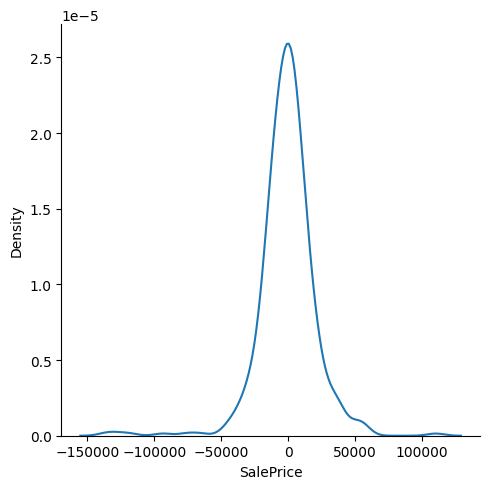

In [ ]:
import seaborn as sns
sns.displot(reg_pred-y_test,kind='kde')

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,reg_pred)


0.9351183881267568